# CREAM Noisy-Graph Analysis
This notebook compares **CREAM with ground-truth DAG** vs **CREAM with noisy DAGs** for:
- `CelebA`
- `Complete_Concept_FMNIST`

Workflow:
1. Locate experiment results CSVs
2. Visualize ground-truth vs noisy DAGs
3. Compare metrics (`test_task_accuracy`, `test_concept_accuracy`, `CCI`, `concept_leakage`)
4. Summarize GT-vs-noisy deltas per dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

# Try server path first, then local workspace path
EXPERIMENTS_ROOT_CANDIDATES = [
    Path('/home/dani00003/mCREAM/experiments'),
    Path(r'c:/Daten/D_Part/Personal/mCREAM/experiments'),
]
EXPERIMENTS_ROOT = next((p for p in EXPERIMENTS_ROOT_CANDIDATES if p.exists()), EXPERIMENTS_ROOT_CANDIDATES[-1])

PROJECT_ROOT = EXPERIMENTS_ROOT.parent if EXPERIMENTS_ROOT.name == 'experiments' else Path(r'c:/Daten/D_Part/Personal/mCREAM')

DATASET_SPECS = {
    'CelebA': {
        'model_folder': 'Standard_CelebA',
        'ground_truth_dag': PROJECT_ROOT / 'data/CelebA/final_DAG_unfair.csv',
        'noisy_dir': PROJECT_ROOT / 'data/CelebA/noisy_dags',
    },
    'Complete_Concept_FMNIST': {
        'model_folder': 'Standard_FashionMNIST',
        'ground_truth_dag': PROJECT_ROOT / 'data/FashionMNIST/Complete_Concept_FMNIST_DAG.csv',
        'noisy_dir': PROJECT_ROOT / 'data/FashionMNIST/noisy_dags',
    },
}

NOISY_LEVELS = ['low', 'medium', 'high', 'structured_bias']
METRICS = [
    'test_task_accuracy',
    'test_concept_accuracy',
    'CCI',
    'PFI_concept_importance',
    'PFI_side_importance',
    'concept_leakage',
    'c2y_baseline_accuracy',
]

print(f'Using EXPERIMENTS_ROOT: {EXPERIMENTS_ROOT}')
print(f'Exists: {EXPERIMENTS_ROOT.exists()}')
print(f'Using PROJECT_ROOT: {PROJECT_ROOT}')

Using EXPERIMENTS_ROOT: /home/dani00003/mCREAM/experiments
Exists: True
Using PROJECT_ROOT: /home/dani00003/mCREAM


## 1) Ground-Truth vs Noisy Graphs
This section shows the ground-truth DAG first, then each noisy DAG level used in CREAM-noisy experiments.

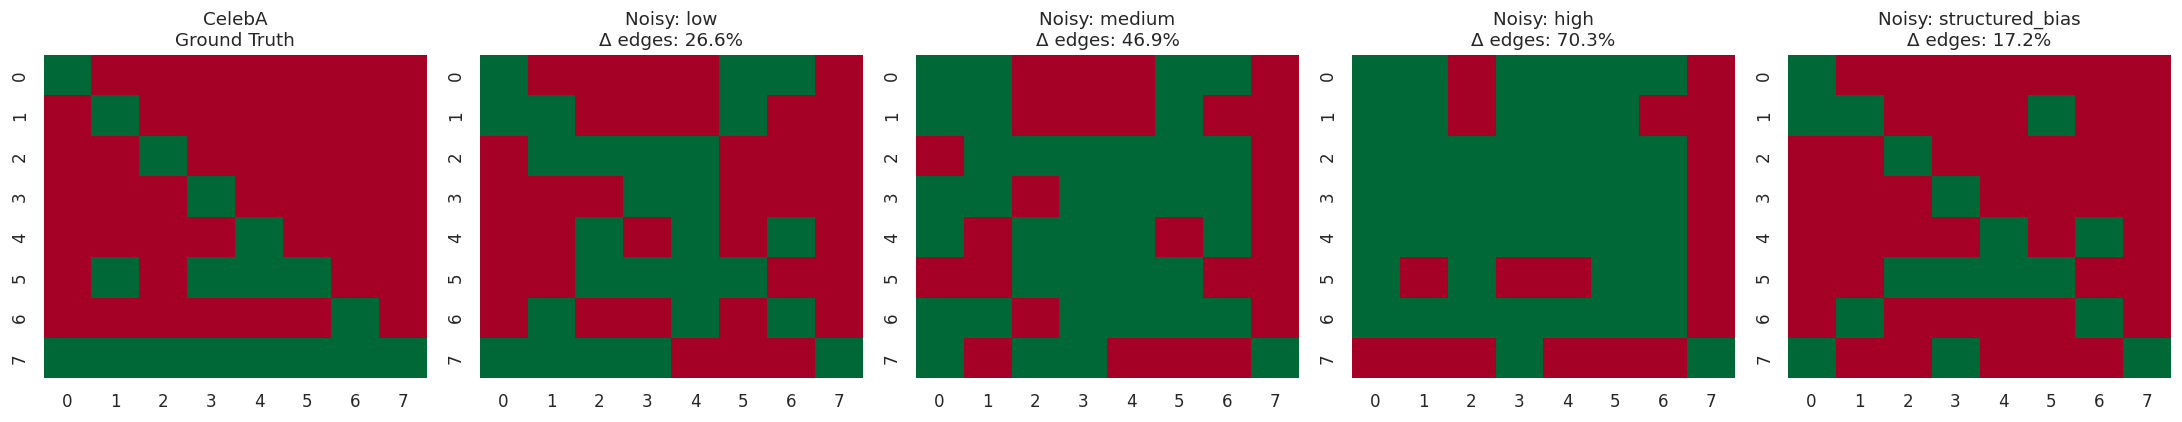

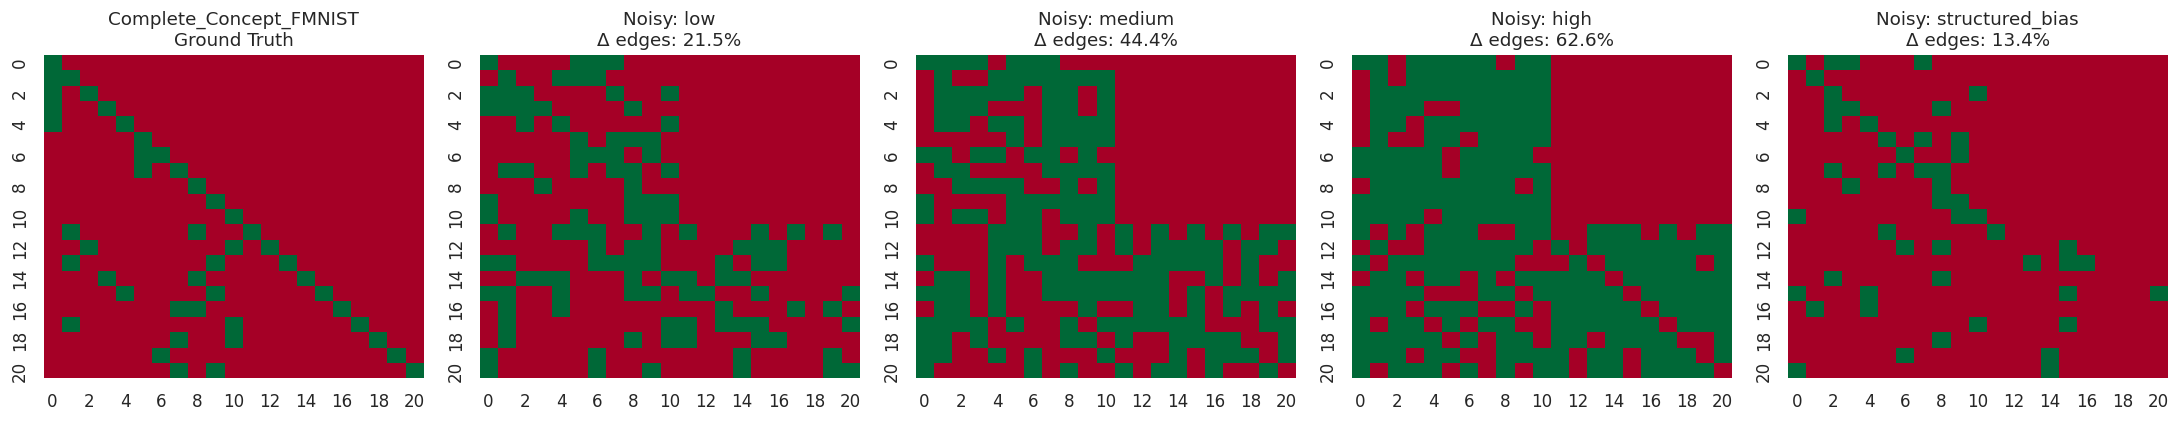

In [2]:
def read_dag_csv(path: Path):
    if not path.exists():
        return None
    return pd.read_csv(path, index_col=0)

def plot_gt_vs_noisy_for_dataset(dataset_name: str):
    spec = DATASET_SPECS[dataset_name]
    gt_path = spec['ground_truth_dag']
    noisy_dir = spec['noisy_dir']

    gt_df = read_dag_csv(gt_path)
    if gt_df is None:
        print(f'[MISS] Ground truth DAG not found: {gt_path}')
        return

    noisy_paths = {
        lvl: noisy_dir / f'noisy_dag_{lvl}.csv' for lvl in NOISY_LEVELS
    }

    cols = 1 + len(NOISY_LEVELS)
    fig, axes = plt.subplots(1, cols, figsize=(4*cols, 4), squeeze=False)
    axes = axes[0]

    sns.heatmap(gt_df.values.astype(float), ax=axes[0], vmin=0, vmax=1, cbar=False, cmap='RdYlGn')
    axes[0].set_title(f'{dataset_name}\nGround Truth')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')

    for i, lvl in enumerate(NOISY_LEVELS, start=1):
        dag_df = read_dag_csv(noisy_paths[lvl])
        if dag_df is None:
            axes[i].axis('off')
            axes[i].set_title(f'{lvl}\nmissing')
            continue

        sns.heatmap(dag_df.values.astype(float), ax=axes[i], vmin=0, vmax=1, cbar=False, cmap='RdYlGn')
        diff_pct = (dag_df.values.astype(bool) != gt_df.values.astype(bool)).mean() * 100
        axes[i].set_title(f'Noisy: {lvl}\nΔ edges: {diff_pct:.1f}%')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    plt.tight_layout()
    plt.show()

for ds in DATASET_SPECS.keys():
    plot_gt_vs_noisy_for_dataset(ds)

## 2) Load CREAM Ground-Truth and CREAM-Noisy Results
This section scans `experiments/<dataset>/train_cbm/<model>/.../last_metrics/*.csv` and labels each run as:
- `ground_truth` (CREAM baseline configs)
- `noisy` (CREAM noisy configs)

In [3]:
def infer_condition_from_filename(stem: str):
    s = stem.lower()
    side_channel_mode = 'no_side' if 'no_side' in s else 'with_side'

    if 'cream_noisy' in s:
        level = next((lvl for lvl in NOISY_LEVELS if lvl in s), None)
        return 'noisy', level, side_channel_mode
    if 'cream_best' in s or 'cream_cgm_pdag' in s:
        return 'ground_truth', 'ground_truth', side_channel_mode
    return None, None, None

def load_cream_gt_noisy_results(experiments_root: Path):
    rows = []

    for dataset_name, spec in DATASET_SPECS.items():
        model_folder = spec['model_folder']
        base = experiments_root / dataset_name / 'train_cbm' / model_folder
        if not base.exists():
            print(f'[SKIP] Missing folder: {base}')
            continue

        for csv_f in base.rglob('last_metrics/*.csv'):
            stem = csv_f.stem
            condition, noisy_level, side_channel_mode = infer_condition_from_filename(stem)
            if condition is None:
                continue

            try:
                df = pd.read_csv(csv_f)
                if len(df) == 0 or str(csv_f).rfind('preset1') != -1:
                    continue
                row = df.iloc[0].to_dict()
                row['dataset'] = dataset_name
                row['condition'] = condition
                row['noisy_level'] = noisy_level
                row['side_channel_mode'] = side_channel_mode
                row['config_name'] = stem
                row['source_file'] = str(csv_f)
                rows.append(row)
            except Exception as exc:
                print(f'[ERR] {csv_f}: {exc}')

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    return out

def make_summary_table(df, metric_cols, group_cols):
    available = [c for c in metric_cols if c in df.columns]
    if not available:
        return pd.DataFrame()

    grouped = df.groupby(group_cols)[available]
    means = grouped.mean(numeric_only=True)
    stds = grouped.std(numeric_only=True).fillna(0.0)
    counts = grouped.size().rename('n_runs')

    summary = pd.DataFrame(index=means.index)
    summary['n_runs'] = counts
    for col in available:
        summary[col] = means[col].map(lambda x: f'{x:.4f}') + ' ± ' + stds[col].map(lambda x: f'{x:.4f}')
    return summary

results_df = load_cream_gt_noisy_results(EXPERIMENTS_ROOT)
print(f'Loaded rows: {len(results_df)}')
if len(results_df) > 0:
    print('Datasets:', sorted(results_df['dataset'].unique()))
    print('Conditions:', sorted(results_df['condition'].unique()))
    print('Noisy levels:', sorted(results_df['noisy_level'].dropna().unique()))
    print('Side modes:', sorted(results_df['side_channel_mode'].dropna().unique()))
    display(results_df[['dataset','condition','side_channel_mode','noisy_level','config_name','source_file']].head(20))

Loaded rows: 18
Datasets: ['CelebA', 'Complete_Concept_FMNIST']
Conditions: ['ground_truth', 'noisy']
Noisy levels: ['ground_truth', 'high', 'low', 'medium', 'structured_bias']
Side modes: ['no_side', 'with_side']


,dataset,condition,side_channel_mode,noisy_level,config_name,source_file
0,CelebA,noisy,no_side,structured_bias,CREAM_noisy_structured_bias_no_side,/home/dani00003/mCREAM/experiments/CelebA/trai...
1,CelebA,noisy,no_side,low,CREAM_noisy_low_no_side,/home/dani00003/mCREAM/experiments/CelebA/trai...
2,CelebA,noisy,no_side,high,CREAM_noisy_high_no_side,/home/dani00003/mCREAM/experiments/CelebA/trai...
3,CelebA,noisy,no_side,medium,CREAM_noisy_medium_no_side,/home/dani00003/mCREAM/experiments/CelebA/trai...
4,CelebA,noisy,with_side,high,CREAM_noisy_high,/home/dani00003/mCREAM/experiments/CelebA/trai...
5,CelebA,noisy,with_side,structured_bias,CREAM_noisy_structured_bias,/home/dani00003/mCREAM/experiments/CelebA/trai...
6,CelebA,noisy,with_side,medium,CREAM_noisy_medium,/home/dani00003/mCREAM/experiments/CelebA/trai...
7,CelebA,noisy,with_side,low,CREAM_noisy_low,/home/dani00003/mCREAM/experiments/CelebA/trai...
8,CelebA,ground_truth,with_side,ground_truth,CREAM_best_celeba,/home/dani00003/mCREAM/experiments/CelebA/trai...
9,Complete_Concept_FMNIST,noisy,no_side,structured_bias,CREAM_noisy_structured_bias_no_side,/home/dani00003/mCREAM/experiments/Complete_Co...


## 3) Metric Tables: Ground-Truth vs Noisy (Both Datasets)

In [4]:
if len(results_df) == 0:
    print('No CREAM GT/Noisy rows found. Check EXPERIMENTS_ROOT and finished runs.')
else:
    if 'side_channel_mode' not in results_df.columns:
        results_df = results_df.copy()
        results_df['side_channel_mode'] = np.where(
            results_df['config_name'].str.lower().str.contains('no_side', na=False),
            'no_side',
            'with_side'
        )

    available_metrics = [m for m in METRICS if m in results_df.columns]
    missing_metrics = [m for m in METRICS if m not in results_df.columns]

    if missing_metrics:
        print(f'Skipping missing metrics: {missing_metrics}')

    if not available_metrics:
        print('None of the requested METRICS are available in results_df.')
    else:
        summary = make_summary_table(
            results_df,
            metric_cols=available_metrics,
            group_cols=['dataset', 'side_channel_mode', 'condition', 'noisy_level']
        )
        print('=' * 90)
        print('CREAM: GROUND-TRUTH vs NOISY SUMMARY (split by side mode)')
        print('=' * 90)
        display(summary)

        raw_means = (
            results_df.groupby(['dataset', 'side_channel_mode', 'condition', 'noisy_level'])[available_metrics]
            .mean(numeric_only=True)
            .reset_index()
        )
        display(raw_means)

Skipping missing metrics: ['concept_leakage', 'c2y_baseline_accuracy']
CREAM: GROUND-TRUTH vs NOISY SUMMARY (split by side mode)


n_runs  \
dataset                 side_channel_mode condition    noisy_level               
CelebA                  no_side           noisy        high                  1   
                                                       low                   1   
                                                       medium                1   
                                                       structured_bias       1   
                        with_side         ground_truth ground_truth          1   
                                          noisy        high                  1   
                                                       low                   1   
                                                       medium                1   
                                                       structured_bias       1   
Complete_Concept_FMNIST no_side           noisy        high                  1   
                                                       low                   1   
                                                       medium                1   
                                                       structured_bias       1   
                        with_side         ground_truth ground_truth          1   
                                          noisy        high                  1   
                                                       low                   1   
                                                       medium                1   
                                                       structured_bias       1   

                                                                       test_task_accuracy  \
dataset                 side_channel_mode condition    noisy_level                          
CelebA                  no_side           noisy        high               0.7936 ± 0.0000   
                                                       low                0.7991 ± 0.0000   
                                                       medium             0.8104 ± 0.0000   
                                                       structured_bias    0.7974 ± 0.0000   
                        with_side         ground_truth ground_truth       0.8163 ± 0.0000   
                                          noisy        high               0.7757 ± 0.0000   
                                                       low                0.8088 ± 0.0000   
                                                       medium             0.8027 ± 0.0000   
                                                       structured_bias    0.7794 ± 0.0000   
Complete_Concept_FMNIST no_side           noisy        high               0.9236 ± 0.0000   
                                                       low                0.9223 ± 0.0000   
                                                       medium             0.9242 ± 0.0000   
                                                       structured_bias    0.8714 ± 0.0000   
                        with_side         ground_truth ground_truth       0.9231 ± 0.0000   
                                          noisy        high               0.9253 ± 0.0000   
                                                       low                0.9249 ± 0.0000   
                                                       medium             0.9256 ± 0.0000   
                                                       structured_bias    0.8247 ± 0.0000   

                                                                       test_concept_accuracy  \
dataset                 side_channel_mode condition    noisy_level                             
CelebA                  no_side           noisy        high                  0.8080 ± 0.0000   
                                                       low                   0.7688 ± 0.0000   
                                                       medium                0.8090 ± 0.0000   
                                                       structured_bias       0.7735 ± 0.00

,dataset,side_channel_mode,condition,noisy_level,test_task_accuracy,test_concept_accuracy,CCI,PFI_concept_importance,PFI_side_importance
0,CelebA,no_side,noisy,high,0.793558,0.808028,NaN,0.293090,3.356158e-09
1,CelebA,no_side,noisy,low,0.799118,0.768839,NaN,0.299562,1.519826e-08
2,CelebA,no_side,noisy,medium,0.810390,0.808980,NaN,0.310151,1.664941e-08
3,CelebA,no_side,noisy,structured_bias,0.797415,0.773491,NaN,0.297328,-1.098216e-08
4,CelebA,with_side,ground_truth,ground_truth,0.816251,0.810454,1.000000,0.316497,-1.597459e-08
5,CelebA,with_side,noisy,high,0.775674,0.795733,1.000000,0.275975,2.648498e-08
6,CelebA,with_side,noisy,low,0.808787,0.787303,1.000000,0.309285,-4.484830e-09
7,CelebA,with_side,noisy,medium,0.802725,0.800542,1.000000,0.303190,1.804681e-08
8,CelebA,with_side,noisy,structured_bias,0.779381,0.796921,1.000000,0.279808,-2.522493e-08
9,Complete_Concept_FMNIST,no_side,noisy,high,0.923600,0.954355,NaN,0.823388,1.802444e-08


## 4) Plots: Accuracy and Reliance Deltas (GT baseline)

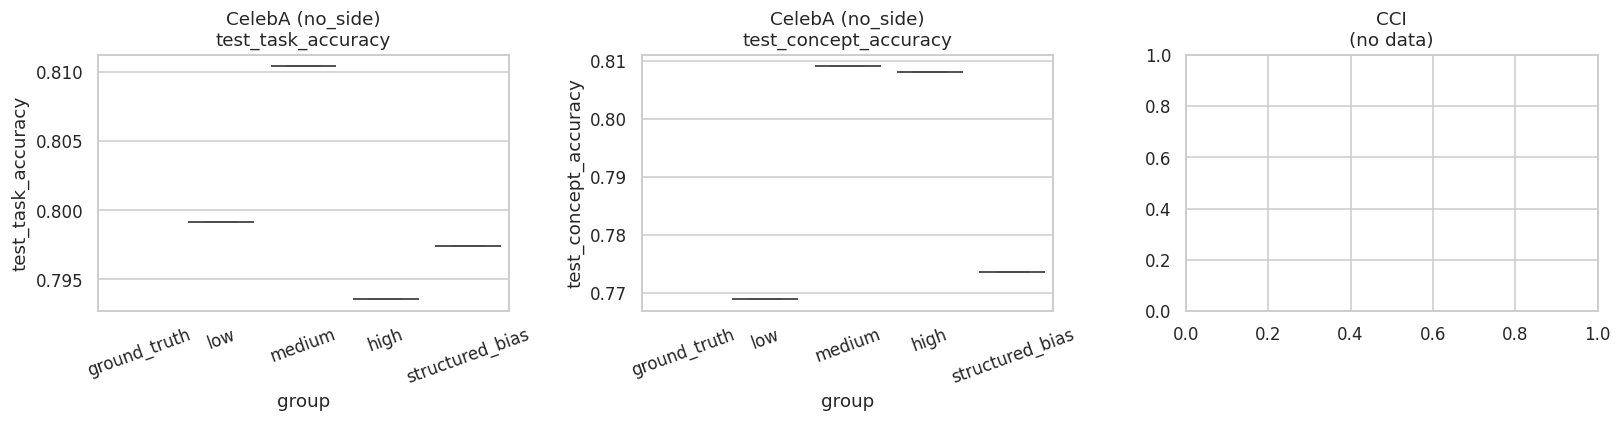

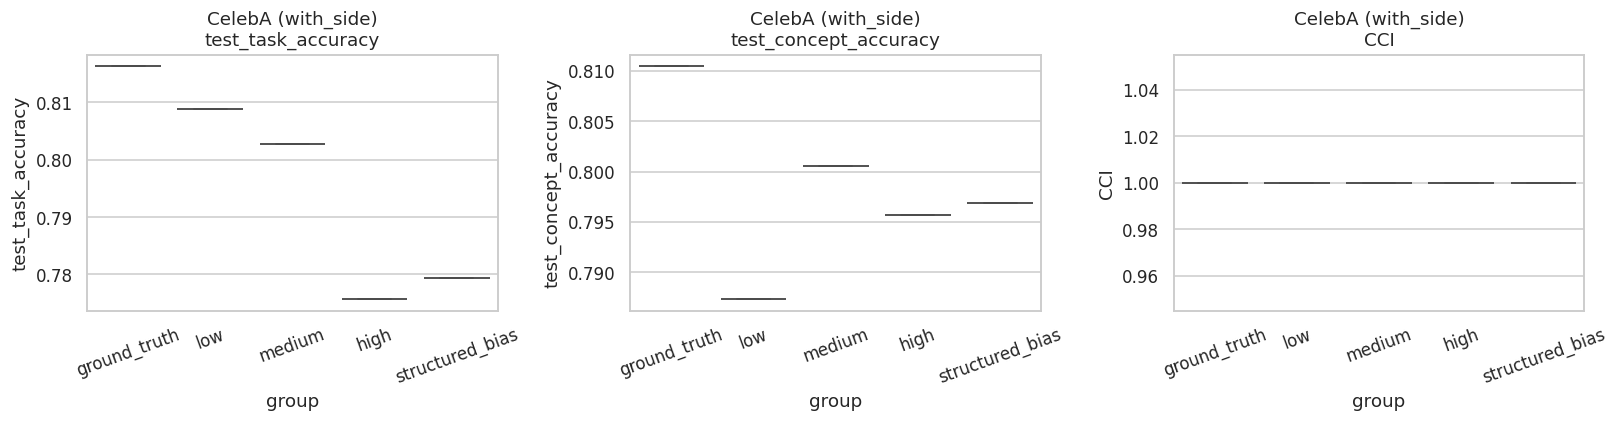

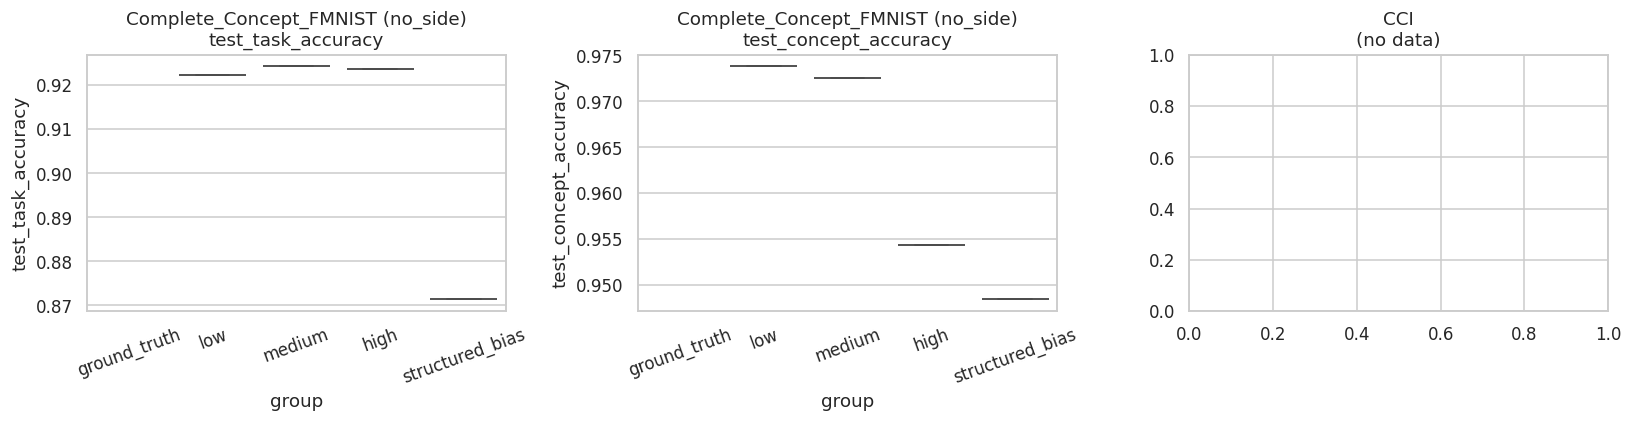

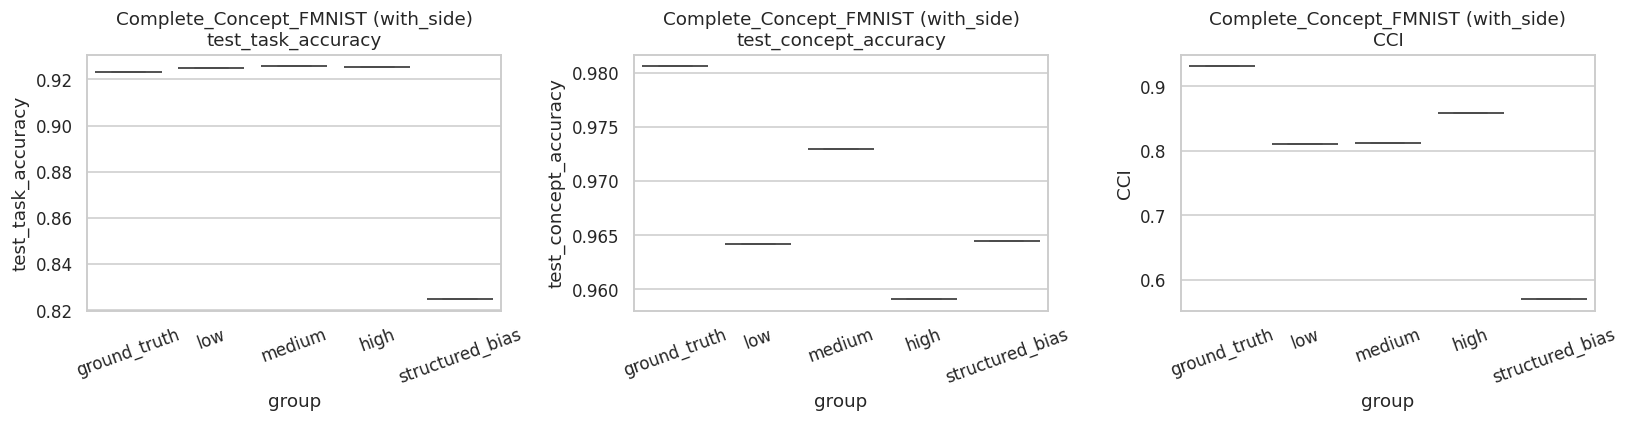

DELTA TABLE (noisy - ground_truth), split by side mode


,dataset,side_channel_mode,noisy_level,delta_test_task_accuracy,delta_test_concept_accuracy,delta_CCI
0,CelebA,with_side,high,-0.040577,-0.014721,0.000000
1,CelebA,with_side,low,-0.007464,-0.023151,0.000000
2,CelebA,with_side,medium,-0.013526,-0.009912,0.000000
3,CelebA,with_side,structured_bias,-0.036870,-0.013533,0.000000
4,Complete_Concept_FMNIST,with_side,high,0.002200,-0.021500,-0.071846
5,Complete_Concept_FMNIST,with_side,low,0.001800,-0.016355,-0.120971
6,Complete_Concept_FMNIST,with_side,medium,0.002500,-0.007618,-0.118445
7,Complete_Concept_FMNIST,with_side,structured_bias,-0.098400,-0.016073,-0.361431


In [6]:
if len(results_df) == 0:
    print('No data to plot.')
else:
    if 'side_channel_mode' not in results_df.columns:
        results_df = results_df.copy()
        results_df['side_channel_mode'] = np.where(
            results_df['config_name'].str.lower().str.contains('no_side', na=False),
            'no_side',
            'with_side'
        )

    metrics_to_plot = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'concept_leakage']
    available = [m for m in metrics_to_plot if m in results_df.columns]

    side_modes = sorted(results_df['side_channel_mode'].dropna().unique())

    # Boxplots by condition/noisy level, split by side mode
    for ds in sorted(results_df['dataset'].unique()):
        for side_mode in side_modes:
            subset = results_df[
                (results_df['dataset'] == ds) &
                (results_df['side_channel_mode'] == side_mode)
            ].copy()
            if subset.empty:
                continue

            subset['group'] = np.where(
                subset['condition'] == 'ground_truth',
                'ground_truth',
                subset['noisy_level']
            )

            fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4), squeeze=False)
            axes = axes[0]
            for ax, metric in zip(axes, available):
                plot_df = subset.dropna(subset=[metric])
                if plot_df.empty:
                    ax.set_title(f'{metric}\n(no data)')
                    continue
                order = ['ground_truth'] + [lvl for lvl in NOISY_LEVELS if lvl in plot_df['group'].values]
                sns.boxplot(data=plot_df, x='group', y=metric, ax=ax, order=order)
                ax.set_title(f'{ds} ({side_mode})\n{metric}')
                ax.tick_params(axis='x', rotation=20)
                if metric == 'concept_leakage':
                    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

    # Delta table: noisy_mean - ground_truth_mean per dataset and side mode
    mean_df = results_df.groupby(['dataset', 'side_channel_mode', 'condition', 'noisy_level'])[available].mean(numeric_only=True).reset_index()
    delta_rows = []
    for ds in sorted(mean_df['dataset'].unique()):
        for side_mode in sorted(mean_df['side_channel_mode'].dropna().unique()):
            gt = mean_df[
                (mean_df['dataset'] == ds) &
                (mean_df['side_channel_mode'] == side_mode) &
                (mean_df['condition'] == 'ground_truth')
            ]
            if gt.empty:
                continue
            gt_vals = gt.iloc[0]
            noisy_df = mean_df[
                (mean_df['dataset'] == ds) &
                (mean_df['side_channel_mode'] == side_mode) &
                (mean_df['condition'] == 'noisy')
            ]
            for _, r in noisy_df.iterrows():
                row = {
                    'dataset': ds,
                    'side_channel_mode': side_mode,
                    'noisy_level': r['noisy_level']
                }
                for m in available:
                    row[f'delta_{m}'] = r[m] - gt_vals[m]
                delta_rows.append(row)

    delta_df = pd.DataFrame(delta_rows)
    if len(delta_df) > 0:
        print('=' * 90)
        print('DELTA TABLE (noisy - ground_truth), split by side mode')
        print('=' * 90)
        display(delta_df.sort_values(['dataset', 'side_channel_mode', 'noisy_level']))
    else:
        print('No GT baseline rows found for delta computation.')

## 5) Side Channel Effect: With vs Without Side Channel
This section directly compares runs with and without side channel.

For each dataset and noisy level, we compute:
- absolute metrics for `with_side` and `no_side`
- delta = `with_side - no_side`

Positive delta means side channel improves the metric; negative means it hurts.

In [7]:
if len(results_df) == 0:
    print('No data to analyze side-channel effect.')
else:
    if 'side_channel_mode' not in results_df.columns:
        results_df = results_df.copy()
        results_df['side_channel_mode'] = np.where(
            results_df['config_name'].str.lower().str.contains('no_side', na=False),
            'no_side',
            'with_side'
        )

    metrics_side_compare = [
        'test_task_accuracy',
        'test_concept_accuracy',
        'CCI',
        'PFI_concept_importance',
        'PFI_side_importance',
    ]
    available_cmp = [m for m in metrics_side_compare if m in results_df.columns]

    if not available_cmp:
        print('No side-comparison metrics found in results_df.')
    else:
        base = (
            results_df
            .groupby(['dataset', 'condition', 'noisy_level', 'side_channel_mode'])[available_cmp]
            .mean(numeric_only=True)
            .reset_index()
        )

        pivot = base.pivot_table(
            index=['dataset', 'condition', 'noisy_level'],
            columns='side_channel_mode',
            values=available_cmp,
            aggfunc='first'
        )

        needed_modes = {'with_side', 'no_side'}
        existing_modes = set(pivot.columns.get_level_values(1).unique())
        missing_modes = needed_modes - existing_modes
        if missing_modes:
            print(f'Missing side modes in data: {sorted(missing_modes)}')

        comparable_rows = pivot.dropna(subset=[(m, 'with_side') for m in available_cmp if ('with_side' in existing_modes)]
                                       + [(m, 'no_side') for m in available_cmp if ('no_side' in existing_modes)],
                                       how='any') if needed_modes.issubset(existing_modes) else pd.DataFrame()

        if comparable_rows.empty:
            print('No matched with_side/no_side rows found for direct comparison.')
        else:
            compare_df = comparable_rows.copy()
            delta_cols = {}
            for m in available_cmp:
                delta_name = f'delta_{m}'
                compare_df[delta_name] = compare_df[(m, 'with_side')] - compare_df[(m, 'no_side')]
                delta_cols[m] = delta_name

            compare_flat = compare_df.copy()
            compare_flat.columns = [f'{a}_{b}' if isinstance(a, str) and isinstance(b, str) else str(col) for (a, b) in compare_flat.columns]
            compare_flat = compare_flat.reset_index()

            print('=' * 90)
            print('WITH_SIDE vs NO_SIDE (matched rows): absolute metrics and deltas')
            print('=' * 90)
            display(compare_flat)

            plot_metrics = ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_side_importance']
            plot_metrics = [m for m in plot_metrics if m in delta_cols]

            for ds in sorted(compare_flat['dataset'].unique()):
                ds_df = compare_flat[compare_flat['dataset'] == ds].copy()
                if ds_df.empty:
                    continue

                noisy_order = [lvl for lvl in NOISY_LEVELS if lvl in ds_df['noisy_level'].values]

                ncols = len(plot_metrics)
                fig, axes = plt.subplots(1, ncols, figsize=(4.8 * ncols, 4), squeeze=False)
                axes = axes[0]

                for ax, m in zip(axes, plot_metrics):
                    dcol = f'delta_{m}'
                    sns.barplot(
                        data=ds_df,
                        x='noisy_level',
                        y=dcol,
                        hue='condition',
                        order=noisy_order if noisy_order else None,
                        ax=ax
                    )
                    ax.axhline(0, color='black', linestyle='--', linewidth=1)
                    ax.set_title(f'{ds}\nΔ {m} (with_side - no_side)')
                    ax.set_xlabel('noisy_level')
                    ax.tick_params(axis='x', rotation=20)
                    if ax.get_legend() is not None:
                        ax.get_legend().set_title('condition')

                plt.tight_layout()
                plt.show()

KeyError: [['CCI', 'no_side']]